Lab Lezione 6: Physics informed neural networks - PINN for Stoke's law

### **Hands on: Stokes' law implemented by PINN**

**Goal**: the purpose of the next exercise consists of predicting the velocity trend for a sphere in a viscous fluid, in the $[0, 2\tau]$ domain ($\tau$ being the time length for damping). At the end, plot the predicted model and compare it with the true solution of the equation. The following steps are required:


1.   Train the PINN over the STOKES_dataset.npz dataset
2.   Compare the result with a model trained without any help from the differential equation
3.   Train the PINN over the STOKES_dataset_noisy.npz dataset



**Hints**

1.   The model has to be trained on both the given data and the constraint given by Stokes' law. The differential equation Stokes' law obeys to, in its scalar fashion, is given by $\dot v + v/\tau - V = 0$. For sake of simplicity, we merged all the dynamical parameters, such as $R$, $\rho_f$, $\rho_s$ and so on into $\tau$ and $V$, $\tau$ being the time length of the system and $V$ the average velocity after damping.
2.   In order to train the PINN, we need to fit the data into the differential equation. Remember, the overall loss is provided by the sum of the loss on the differential equation and on the data training. Handling non-noisy data, you may just sum the two losses, while on noisy data different weights may help the training.
3.   As far as we are performing a regression, MSE loss will come in handy for our task, both for the differential equation and the dataset.
4.   The model has to be trained into the $[0;2\tau]$ domain. Nevertheless, the dataset provides times ranged into the $[0;τ]$ interval. A useful suggestion would be to generate a set of times $t_{eq}$ ranged in $[0;2\tau]$ in order to train the loss on the differential equation. In fact, the training on the differential equation does just need a set of $t$ as inputs, regardless of beloning to the dataset or being randomly generated. Therefore, use random generated times for the training on the differential equation and the dataset $\{t_i, v_i\}_{i=1}^{10}$ for the boundary conditions.
5.   As the dataset is very tiny (ten elements), you will see the power of PINN when fitting the curve!


Base code

In [ ]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt


## For further inspiration, take a look at
## https://github.com/nanditadoloi/PINN/blob/main/solve_PDE_NN.ipynb


###########
## MODEL ##
###########
class PINN(nn.Module):
    def __init__(self, tau, V):
        super(PINN, self).__init__()
        self.hidden_layer1 = nn.Linear(1,5)
        self.hidden_layer2 = nn.Linear(5,5)
        self.hidden_layer3 = nn.Linear(5,5)
        self.hidden_layer4 = nn.Linear(5,5)
        self.hidden_layer5 = nn.Linear(5,5)
        self.output_layer = nn.Linear(5,1)

        ## Diff. Eq. Params ##
        self.tau, self.V = tau, V

        ## TODO: define the optimizer


        ## TODO: define the loss function


    def forward(self, t):
        inputs = torch.cat([t], axis=1)
        layer1_out = torch.sigmoid(self.hidden_layer1(inputs))
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
        layer3_out = torch.sigmoid(self.hidden_layer3(layer2_out))
        layer4_out = torch.sigmoid(self.hidden_layer4(layer3_out))
        layer5_out = torch.sigmoid(self.hidden_layer5(layer4_out))
        ## For regression, no activation is used in output layer ##
        output = self.output_layer(layer5_out)
        return output

    def diff_eq(self, t):
        """
        This method returns an implicit function which set = 0 gives the differential equation
        :param t: the times used to estimate the value of the function F(t)
        :return: the implicit function F(t)
        """
        ## TODO: predict the velocities

        ## TODO: derive the velocities with respect to t (first order derivative dv/dt)

        ## TODO: return the implicit function for the differential equation

    def train_step(self, diff_eq_times, dataset_times, dataset_vel):
        """
        This method train the NN model using the data loss and the differential equation loss
        :param diff_eq_times: tensor of times used to estimate the differential equation
        :param dataset_times: tensor of times used to estimate the velocities using the NN
        :param dataset_vel: tensor of "labels" used to estimate the data loss
        :return: the total loss: loss_total = loss_data + loss_diff_eq
        """
        self.optimizer.zero_grad()

        # TODO: estimate the data loss (take inspiration from the parabola.py or the Ising files)

        # Here we estimate the differential equation loss
        f_out = self.diff_eq(diff_eq_times)  # output of f(x,t)
        zeros_diff_eq = torch.zeros(size=(500, 1), requires_grad=False, dtype=torch.float32)
        loss_diff_eq = self.criterion(f_out, zeros_diff_eq)

        # TODO: sum the two losses (loss_total)

        # TODO: compute the total backpropagation


##############
## TRAINING ##
##############
def main():
    ## Data upload ##
    dataset_ = np.load("STOKES_dataset.npz")
    t_dataset, v_dataset = dataset_["times"], dataset_["velocities"]

    ## Parameters ##
    tau_ = 2.0
    V_ = 2.0
    times_min, times_max = 0.0, 2 * tau_

    ## Dataset in tensor format ##
    times_data = torch.tensor(t_dataset, requires_grad=True, dtype=torch.float32)
    velocities = torch.tensor(v_dataset, requires_grad=True, dtype=torch.float32)

    ## TODO: Instantiate the model
    net = ...

    ## TODO: Train the model and define number of epochs and batch size
    n_epochs = ...
    batch_size = ...
    for epoch in range(n_epochs):
        ## Differential Equation data ##
        times_eq = (times_min - times_max) * torch.rand(size=(batch_size, 1), requires_grad=True,
                                                        dtype=torch.float32) + times_max

        loss = net.train_step(diff_eq_times=times_eq, dataset_times=times_data, dataset_vel=velocities)

        print(epoch+1, "Training Loss:", loss)


    ############## TEST ##############
    ## Generate a sequence of times ##
    ## Plot the model predictions   ##
    ## Plot the true dynamic curve  ##
    ## Plot the dataset of (t,v)    ##
    ##################################
    ## Data to plot ##
    with torch.autograd.no_grad():
        t_test = np.arange(0, 2*tau_, 1/200).reshape(800, 1)
        v_true = np.array([2 * np.exp(-t / tau_) + 4 for t in t_test])
        ## TODO: predict the velocities from t_test in order to plot them
        ## use .detach().numpy() method to convert torch.tensor to numpy
        v_test = ...


    ## Plotting ##
    fig, ax = plt.subplots()
    ax.plot(t_test, v_test, label="Model")
    ax.plot(t_test, v_true, '--', label="Ground Truth")
    ax.plot(t_dataset, v_dataset, 'o', label="Dataset")

    ax.legend(loc='upper right', shadow=True)
    ax.set_xlabel('Time (s)', weight='bold')
    ax.set_ylabel('Velocity (m/s)', weight='bold')
    ax.set_title('Stokes Dynamics', fontsize=22, weight='bold')
    plt.show()


if __name__=="__main__":
    main()






New modified code

1 Training Loss: 20.6717529296875
2 Training Loss: 20.626266479492188
3 Training Loss: 20.58078956604004
4 Training Loss: 20.53531837463379
5 Training Loss: 20.489858627319336
6 Training Loss: 20.44440460205078
7 Training Loss: 20.39896011352539
8 Training Loss: 20.353527069091797
9 Training Loss: 20.308103561401367
10 Training Loss: 20.262685775756836
11 Training Loss: 20.21727752685547
12 Training Loss: 20.1718807220459
13 Training Loss: 20.126487731933594
14 Training Loss: 20.08110237121582
15 Training Loss: 20.035722732543945
16 Training Loss: 19.990345001220703
17 Training Loss: 19.94496726989746
18 Training Loss: 19.899595260620117
19 Training Loss: 19.85422134399414
20 Training Loss: 19.808841705322266
21 Training Loss: 19.763460159301758
22 Training Loss: 19.718069076538086
23 Training Loss: 19.67266273498535
24 Training Loss: 19.62724494934082
25 Training Loss: 19.581806182861328
26 Training Loss: 19.536352157592773
27 Training Loss: 19.49087142944336
28 Training Loss: 19.4453

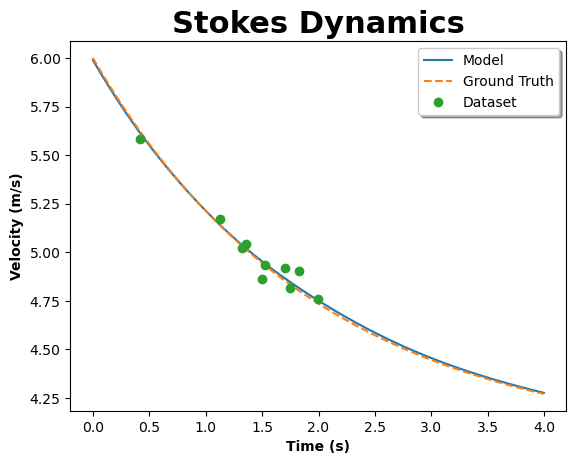

In [ ]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt


## For further inspiration, take a look at
## https://github.com/nanditadoloi/PINN/blob/main/solve_PDE_NN.ipynb


###########
## MODEL ##
###########
class PINN(nn.Module):
    def __init__(self, tau, V):
        super(PINN, self).__init__()
        self.hidden_layer1 = nn.Linear(1,5)
        self.hidden_layer2 = nn.Linear(5,5)
        self.hidden_layer3 = nn.Linear(5,5)
        self.hidden_layer4 = nn.Linear(5,5)
        self.hidden_layer5 = nn.Linear(5,5)
        self.output_layer = nn.Linear(5,1)

        ## Diff. Eq. Params ##
        self.tau, self.V = tau, V

        ## TODO: define the optimizer
        self.optimizer = torch.optim.Adam(self.parameters(), lr=0.001)

        ## TODO: define the loss function
        self.criterion = torch.nn.MSELoss()


    def forward(self, t):
        inputs = torch.cat([t], axis=1)
        layer1_out = torch.sigmoid(self.hidden_layer1(inputs))
        layer2_out = torch.sigmoid(self.hidden_layer2(layer1_out))
        layer3_out = torch.sigmoid(self.hidden_layer3(layer2_out))
        layer4_out = torch.sigmoid(self.hidden_layer4(layer3_out))
        layer5_out = torch.sigmoid(self.hidden_layer5(layer4_out))
        ## For regression, no activation is used in output layer ##
        output = self.output_layer(layer5_out)
        return output

    def diff_eq(self, t):
        """
        This method returns an implicit function which set = 0 gives the differential equation
        :param t: the times used to estimate the value of the function F(t)
        :return: the implicit function F(t)
        """
        ## TODO: predict the velocities
        #vel[0] = v0
        #vel = A*np.exp(-t/tau_) + C
        vel = self.forward(t)
        ## TODO: derive the velocities with respect to t (first order derivative dv/dt)
        #vel_der = -A/tau_ * np.exp(-t/tau_)
        vel_der = torch.autograd.grad(vel.sum(), t, create_graph=True)[0]
        ## TODO: return the implicit function for the differential equation
        
        return vel_der + vel / self.tau - self.V
    


    def train_step(self, diff_eq_times, dataset_times, dataset_vel):
        """
        This method train the NN model using the data loss and the differential equation loss
        :param diff_eq_times: tensor of times used to estimate the differential equation
        :param dataset_times: tensor of times used to estimate the velocities using the NN
        :param dataset_vel: tensor of "labels" used to estimate the data loss
        :return: the total loss: loss_total = loss_data + loss_diff_eq
        """
        #reset gradients
        self.optimizer.zero_grad()

        # TODO: estimate the data loss (take inspiration from the parabola.py or the Ising files)
        # Passing the node features and the connection info
        prediction = self.forward(dataset_times)
        # Calculating the loss and gradients
        loss_data = self.criterion(prediction, dataset_vel)
        # Here we estimate the differential equation loss
        f_out = self.diff_eq(diff_eq_times)  # output of f(x,t)
        zeros_diff_eq = torch.zeros(size=(500, 1), requires_grad=False, dtype=torch.float32)
        loss_diff_eq = self.criterion(f_out, zeros_diff_eq)

        # TODO: sum the two losses (loss_total)
        loss_total = loss_data + loss_diff_eq
        # TODO: compute the total backpropagation
        loss_total.backward()
        self.optimizer.step()

        return loss_total.item()


##############
## TRAINING ##
##############
def main():
    ## Data upload ##
    #dataset_ = np.load("STOKES_dataset.npz")
    dataset_ = np.load("STOKES_dataset_noisy.npz")
    t_dataset, v_dataset = dataset_["times"], dataset_["velocities"]

    ## Parameters ##
    tau_ = 2.0
    V_ = 2.0
    times_min, times_max = 0.0, 2 * tau_
    #learning_rate = 0.01

    ## Dataset in tensor format ##
    times_data = torch.tensor(t_dataset, requires_grad=True, dtype=torch.float32)
    velocities = torch.tensor(v_dataset, requires_grad=True, dtype=torch.float32)

    ## TODO: Instantiate the model
    net = PINN(tau=tau_, V=V_)

    ## TODO: Train the model and define number of epochs and batch size
    n_epochs = 30000
    batch_size = 500
    for epoch in range(n_epochs):
        ## Differential Equation data ##
        times_eq = (times_min - times_max) * torch.rand(size=(batch_size, 1), requires_grad=True,
                                                        dtype=torch.float32) + times_max

        loss = net.train_step(diff_eq_times=times_eq, dataset_times=times_data, dataset_vel=velocities)

        print(epoch+1, "Training Loss:", loss)


    ############## TEST ##############
    ## Generate a sequence of times ##
    ## Plot the model predictions   ##
    ## Plot the true dynamic curve  ##
    ## Plot the dataset of (t,v)    ##
    ##################################
    print(44 * '-')
    print('\nTesting ...')
    ## Data to plot ##
    with torch.autograd.no_grad():
        t_test = np.arange(0, 2*tau_, 1/200).reshape(800, 1)
        v_true = np.array([2 * np.exp(-t / tau_) + 4 for t in t_test])
        ## TODO: predict the velocities from t_test in order to plot them
        ## use .detach().numpy() method to convert torch.tensor to numpy
        t_test = torch.tensor(t_test, dtype=torch.float32)
        v_test = net(t_test)
        v_test = v_test.detach().numpy()


    ## Plotting ##
    fig, ax = plt.subplots()
    ax.plot(t_test, v_test, label="Model")
    ax.plot(t_test, v_true, '--', label="Ground Truth")
    ax.plot(t_dataset, v_dataset, 'o', label="Dataset")

    ax.legend(loc='upper right', shadow=True)
    ax.set_xlabel('Time (s)', weight='bold')
    ax.set_ylabel('Velocity (m/s)', weight='bold')
    ax.set_title('Stokes Dynamics', fontsize=22, weight='bold')
    plt.show()


if __name__=="__main__":
    main()
